# Social Media Sentiment Analysis for Product Development and Feature Improvement

## APSSDC Internship Project

### Team Members

- Sanku Meghana
- Tulasi Gowri Athi
- Reddy Gayathri
- K.S.V.S Kalyan
- Paruchuri Venkatesh
- Kanaparthi Geetanjali

### Problem Statement

- Large volumes of customer feedback make it difficult to manually analyze sentiment and identify meaningful insights.This project aims to automate sentiment classification to better understand customer opinions and support product improvement.

### Project Objective

Analyze Google Play Store reviews to:

- Understand user sentiment
- Identify positive and negative feedback
- Discover frequently discussed features
- Extract actionable insights for product improvement
- Visualize sentiment patterns

### Dataset Description

- The dataset consists of structured and unstructured data, including text-based inputs such as reviews or feedback.
- Key features are analyzed to understand their influence on overall sentiment and trends.

### Installing Required Libraries

- The Required Libraries can be installed using the below command.

In [41]:
# !pip install pandas numpy matplotlib seaborn nltk textblob wordcloud

### Import Libraries

- Importing Essential Python libraries and configured to support data processing, analysis, and visualization.
- This ensures a smooth and efficient workflow throughout the project.

In [42]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

import re
import string

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [43]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ADMIN\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

### Dataset Loading
- The dataset is loading into the environment using appropriate tools and methods.
- Initial checks are performed to verify structure, format, and completeness.

In [44]:
df = pd.read_csv("social_media_reviews.csv")

print("Dataset Loaded Successfully")
print("Shape :", df.shape)

Dataset Loaded Successfully
Shape : (64295, 5)


### Dataset Overview


In [45]:
df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


In [47]:
df.describe(include='all')

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
count,64295,37427,37432,37432.000000,37432.000000
unique,1074,27994,3,NaN,NaN
top,Angry Birds Classic,Good,Positive,NaN,NaN
freq,320,247,23998,NaN,NaN
mean,NaN,NaN,NaN,0.182146,0.492704
std,NaN,NaN,NaN,0.351301,0.259949
min,NaN,NaN,NaN,-1.000000,0.000000
25%,NaN,NaN,NaN,0.000000,0.357143
50%,NaN,NaN,NaN,0.150000,0.514286
75%,NaN,NaN,NaN,0.400000,0.650000


# Missing Values Analysis

- Preprocessing the data by handling missing values, duplicates, and inconsistencies.

In [48]:
df.isnull().sum()


App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64

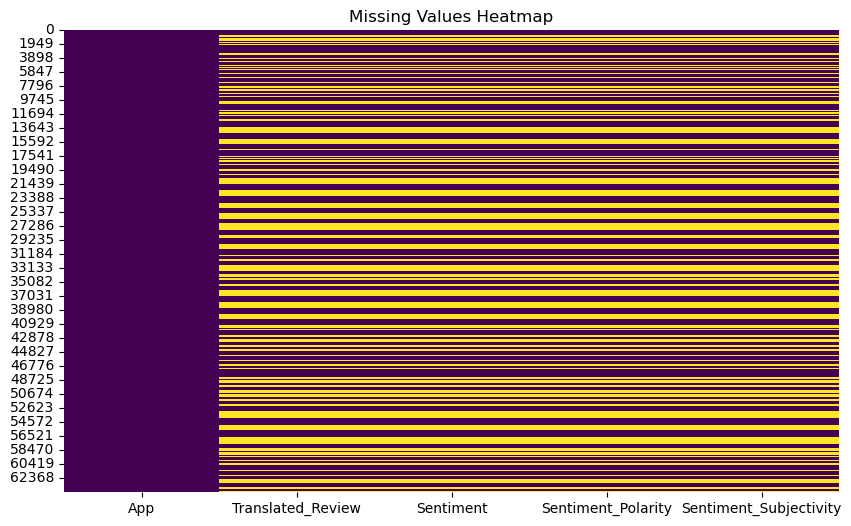

In [49]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

# Data Cleaning

- This step ensures high-quality data for accurate and reliable analysis.
- Prepares clean and reliable data for further analysis.

In [50]:
df = df.dropna(subset=['Translated_Review'])

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"\d+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    tokens = text.split()

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

df["Cleaned_Review"] = df["Translated_Review"].apply(clean_text)

df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Cleaned_Review
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,like eat delicious food thats im cooking food ...
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,help eating healthy exercise regular basis
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,work great especially going grocery store
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,best idea u
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,best way


In [51]:
df[['Translated_Review','Cleaned_Review']].head(10)

,Translated_Review,Cleaned_Review
0,I like eat delicious food. That's I'm cooking ...,like eat delicious food thats im cooking food ...
1,This help eating healthy exercise regular basis,help eating healthy exercise regular basis
3,Works great especially going grocery store,work great especially going grocery store
4,Best idea us,best idea u
5,Best way,best way
6,Amazing,amazing
8,"Looking forward app,",looking forward app
9,It helpful site ! It help foods get !,helpful site help food get
10,good you.,good
11,Useful information The amount spelling errors ...,useful information amount spelling error quest...


# Review Length Analysis

In [52]:
df["Review_Length"] = df["Cleaned_Review"].apply(len)

df["Review_Length"].describe()

count    37427.000000
mean        96.085286
std         90.197303
min          0.000000
25%         27.000000
50%         73.000000
75%        140.000000
max       2297.000000
Name: Review_Length, dtype: float64

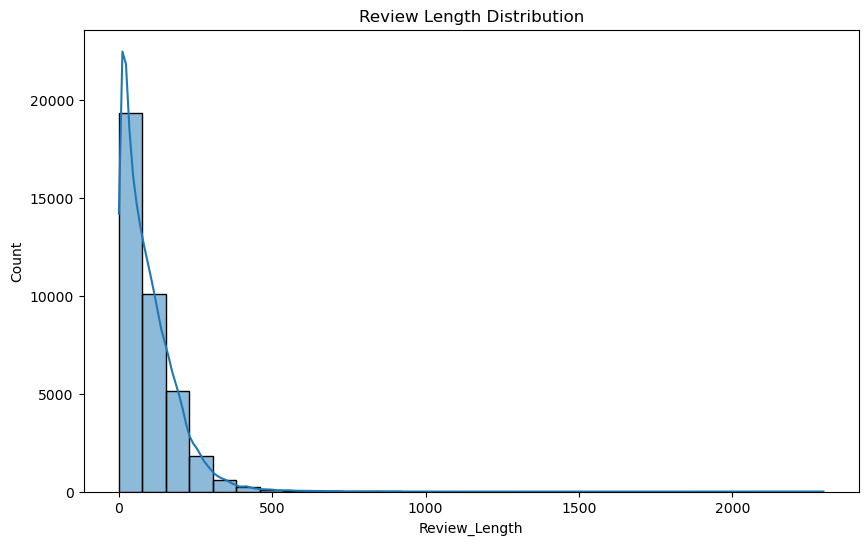

In [53]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["Review_Length"],
    bins=30,
    kde=True
)

plt.title("Review Length Distribution")

plt.show()

# Sentiment Analysis

- Text data is analyzed to classify sentiments into categories such as positive, negative, or neutral.
- This helps in understanding overall customer opinions and emotional tone.

In [54]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Cleaned_Review"].apply(get_sentiment)

df.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Cleaned_Review,Review_Length,Predicted_Sentiment
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,like eat delicious food thats im cooking food ...,90,Positive
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,help eating healthy exercise regular basis,42,Positive
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,work great especially going grocery store,41,Positive
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,best idea u,11,Positive
5,10 Best Foods for You,Best way,Positive,1.00,0.300000,best way,8,Positive


### Exploratory Data Analysis (EDA)

- Data is explored to identify patterns, trends, and relationships between variables.
- Key observations provide a deeper understanding of the dataset’s behavior.

In [55]:
sentiment_counts = df["Predicted_Sentiment"].value_counts()

sentiment_counts

Predicted_Sentiment
Positive    23861
Negative     8189
Neutral      5377
Name: count, dtype: int64

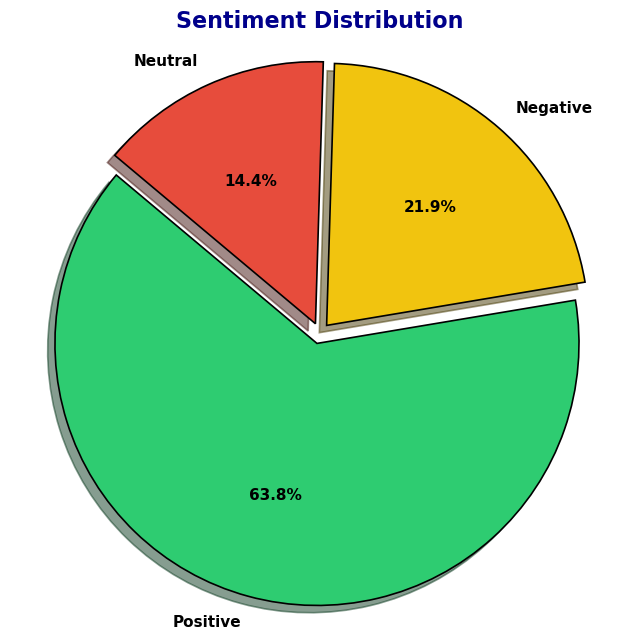

In [56]:
import matplotlib.pyplot as plt

# Professional colors
colors = ['#2ECC71', '#F1C40F', '#E74C3C']

explode = (0.04, 0.04, 0.04)

plt.figure(figsize=(6.5, 6.5))   # Reduced size

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    colors=colors,
    explode=explode,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1.2
    },
    textprops={
        'fontsize': 11,
        'fontweight': 'bold'
    }
)

plt.title(
    "Sentiment Distribution",
    fontsize=16,
    fontweight='bold',
    color='darkblue',
    pad=12
)

plt.axis('equal')
plt.tight_layout()

plt.show()

# Distribution Of Predicted Sentiments

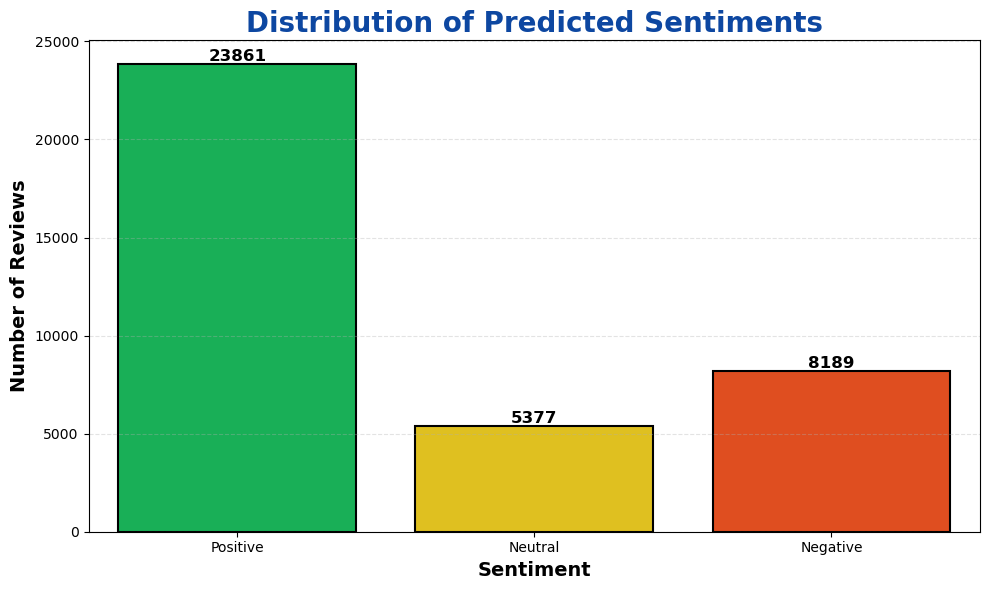

In [57]:
plt.figure(figsize=(10,6))

# Vibrant but professional colors
colors = ['#00C853', '#FFD600', '#FF3D00']

ax = sns.countplot(
    x='Predicted_Sentiment',
    data=df,
    order=['Positive', 'Neutral', 'Negative'],
    palette=colors,
    edgecolor='black',
    linewidth=1.5
)

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=12,
        fontweight='bold'
    )

plt.title(
    "Distribution of Predicted Sentiments",
    fontsize=20,
    fontweight='bold',
    color='#0D47A1'
)

plt.xlabel(
    "Sentiment",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Number of Reviews",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='y', linestyle='--', alpha=0.35)

plt.tight_layout()

plt.show()

# Word Frequency Analysis

- The Word Frequency Analysis identifies the most commonly used terms across customer reviews. Frequently occurring words highlight the key topics, features, and concerns that users discuss most often, providing valuable insights into customer preferences and experiences.

In [58]:
all_words = " ".join(df["Cleaned_Review"])

word_freq = Counter(all_words.split())

top_words = word_freq.most_common(20)

top_words_df = pd.DataFrame(
    top_words,
    columns=["Word","Frequency"]
)

top_words_df

,Word,Frequency
0,game,10242
1,time,5584
2,like,5555
3,good,5240
4,get,5142
5,great,4792
6,app,4767
7,love,4750
8,work,3421
9,ad,3409


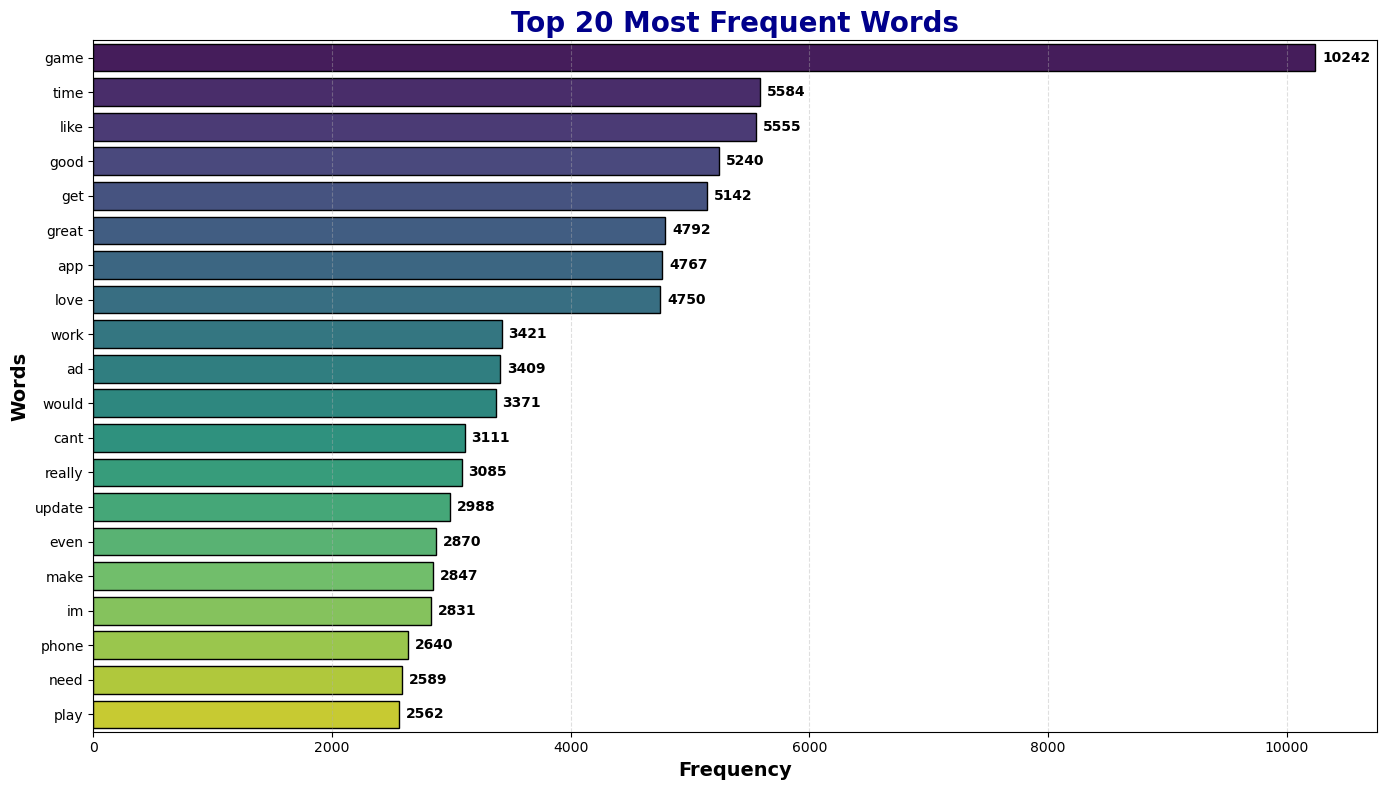

In [59]:
plt.figure(figsize=(14,8))

# Color palette with different colors for each bar
colors = sns.color_palette("viridis", len(top_words_df))

ax = sns.barplot(
    x="Frequency",
    y="Word",
    data=top_words_df,
    palette=colors,
    edgecolor="black"
)

# Add frequency values at the end of each bar
for container in ax.containers:
    ax.bar_label(
        container,
        padding=5,
        fontsize=10,
        fontweight='bold'
    )

plt.title(
    "Top 20 Most Frequent Words",
    fontsize=20,
    fontweight='bold',
    color='darkblue'
)

plt.xlabel(
    "Frequency",
    fontsize=14,
    fontweight='bold'
)

plt.ylabel(
    "Words",
    fontsize=14,
    fontweight='bold'
)

plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

## Positive Review WordCloud

- The Positive Reviews Word Cloud highlights frequently used words such as "good", "great", "love", "easy", and "use". These keywords indicate that users appreciate the application's usability, features, and overall performance.

In [60]:
positive_reviews = df[
    df["Predicted_Sentiment"]=="Positive"
]

positive_text = " ".join(
    positive_reviews["Cleaned_Review"]
)

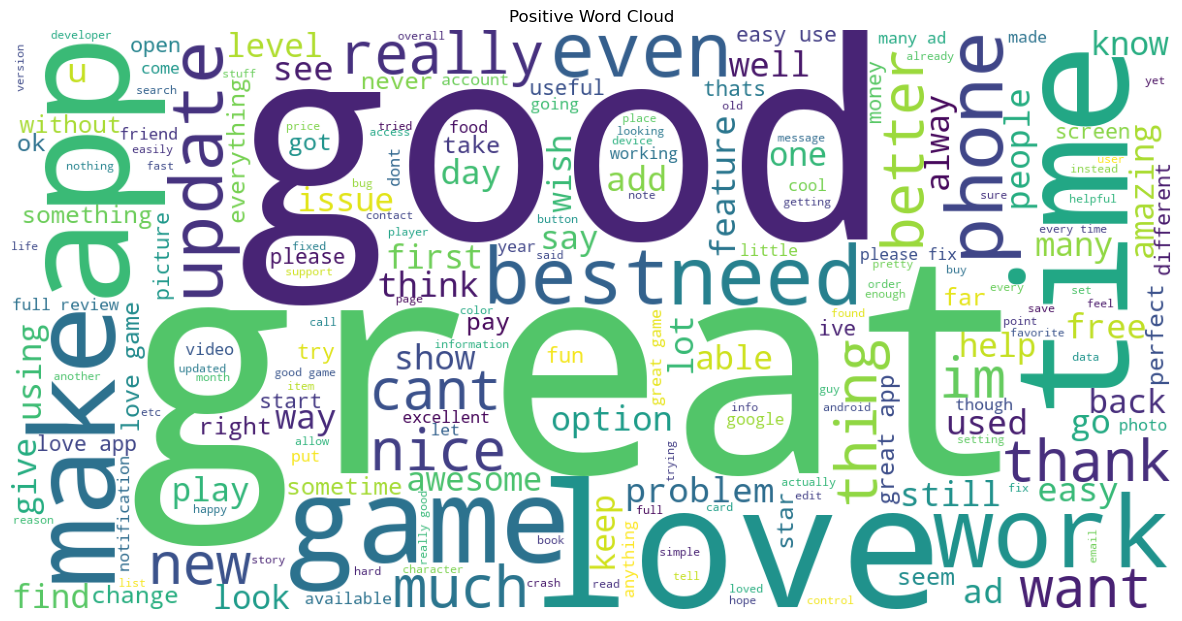

In [61]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Word Cloud")

plt.show()

## Negative Review WordCLoud

- The Negative Reviews Word Cloud highlights frequently occurring words such as "problem", "bad", "issue", "crash", "slow", and "update". These keywords indicate that users primarily express dissatisfaction with application performance, stability, and recent updates.

In [62]:
negative_reviews = df[
    df["Predicted_Sentiment"]=="Negative"
]

negative_text = " ".join(
    negative_reviews["Cleaned_Review"]
)

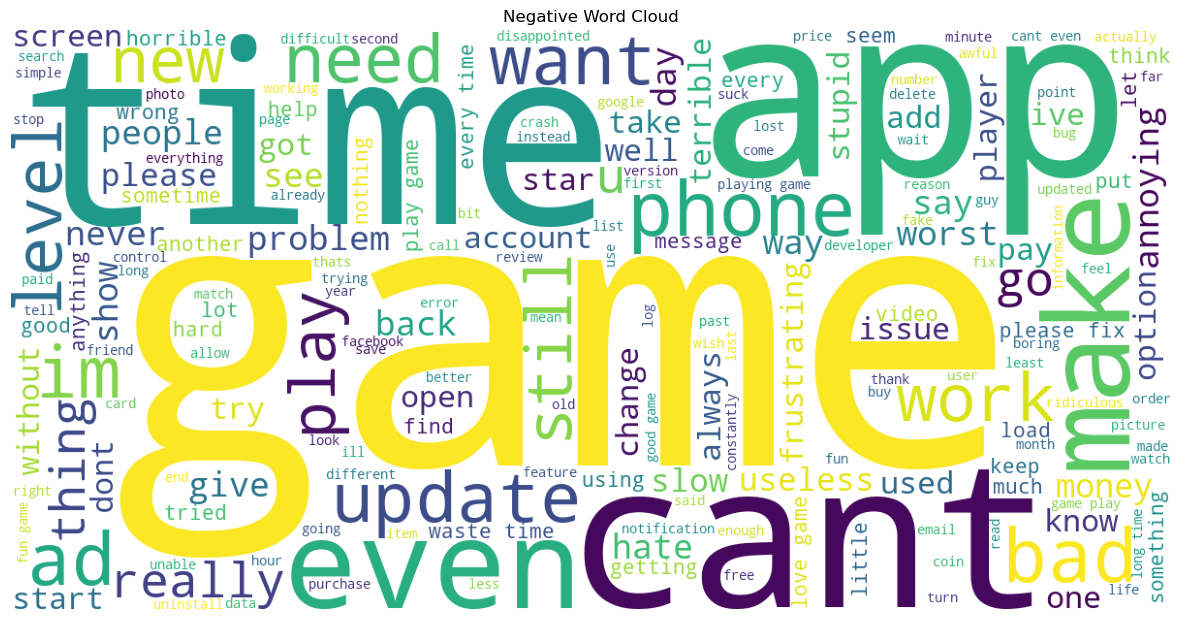

In [63]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Negative Word Cloud")

plt.show()

## Apps With Most Reviews

- The chart identifies the applications that have received the highest number of user reviews. A larger number of reviews indicates higher user engagement and provides a richer source of customer feedback for sentiment analysis.

In [64]:
top_apps = df["App"].value_counts().head(10)

top_apps

App
Bowmasters                        312
Helix Jump                        273
Angry Birds Classic               273
Calorie Counter - MyFitnessPal    254
Duolingo: Learn Languages Free    240
Candy Crush Saga                  240
Garena Free Fire                  222
8 Ball Pool                       219
Calorie Counter - Macros          200
10 Best Foods for You             194
Name: count, dtype: int64

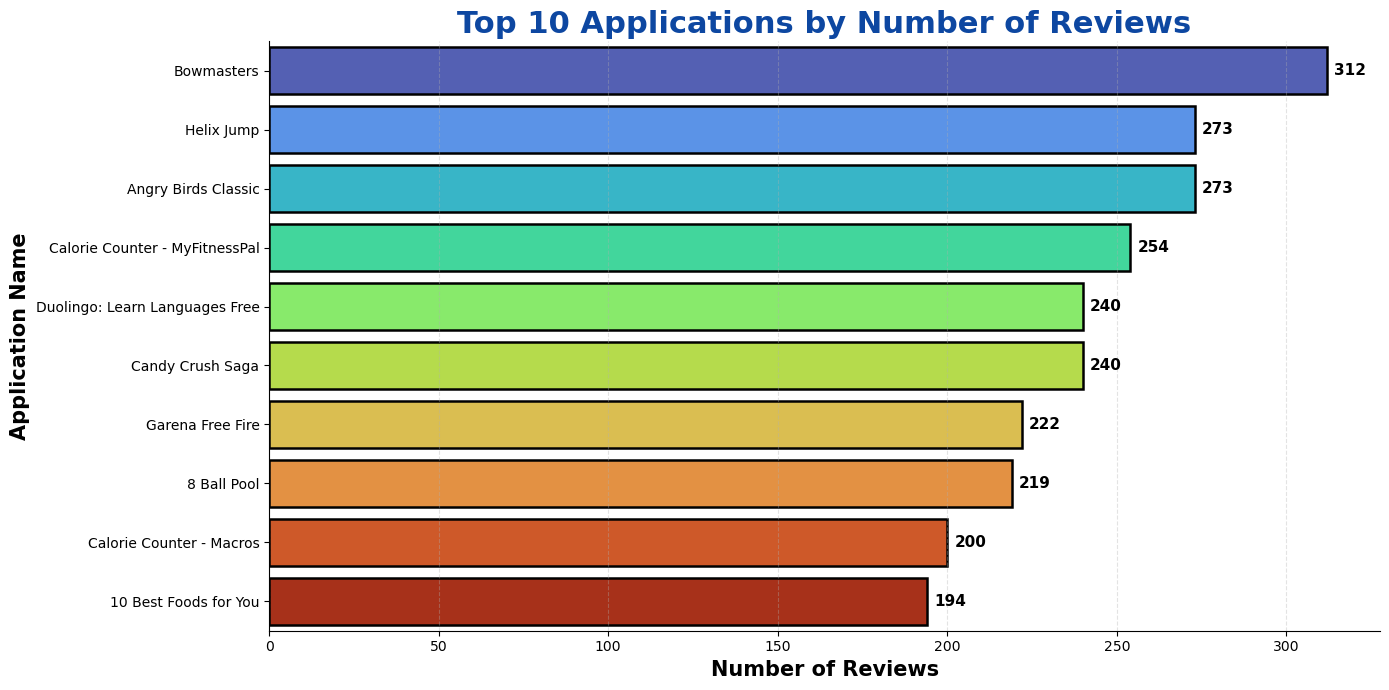

In [65]:
plt.figure(figsize=(14,7))

colors = sns.color_palette(
    "turbo",
    len(top_apps)
)

ax = sns.barplot(
    x=top_apps.values,
    y=top_apps.index,
    palette=colors,
    edgecolor="black",
    linewidth=1.8
)

# Display values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=11,
        fontweight='bold',
        color='black',
        padding=5
    )

plt.title(
    "Top 10 Applications by Number of Reviews",
    fontsize=22,
    fontweight="bold",
    color="#0D47A1"
)

plt.xlabel(
    "Number of Reviews",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "Application Name",
    fontsize=15,
    fontweight="bold"
)

plt.grid(axis='x', linestyle='--', alpha=0.35)

sns.despine()   

plt.tight_layout()

plt.show()

# Business Dashboard

- The dashboard shows that the majority of customer reviews are positive, indicating a generally high level of user satisfaction. This suggests that the application's core features are well accepted by users, while maintaining customer satisfaction should remain a priority.

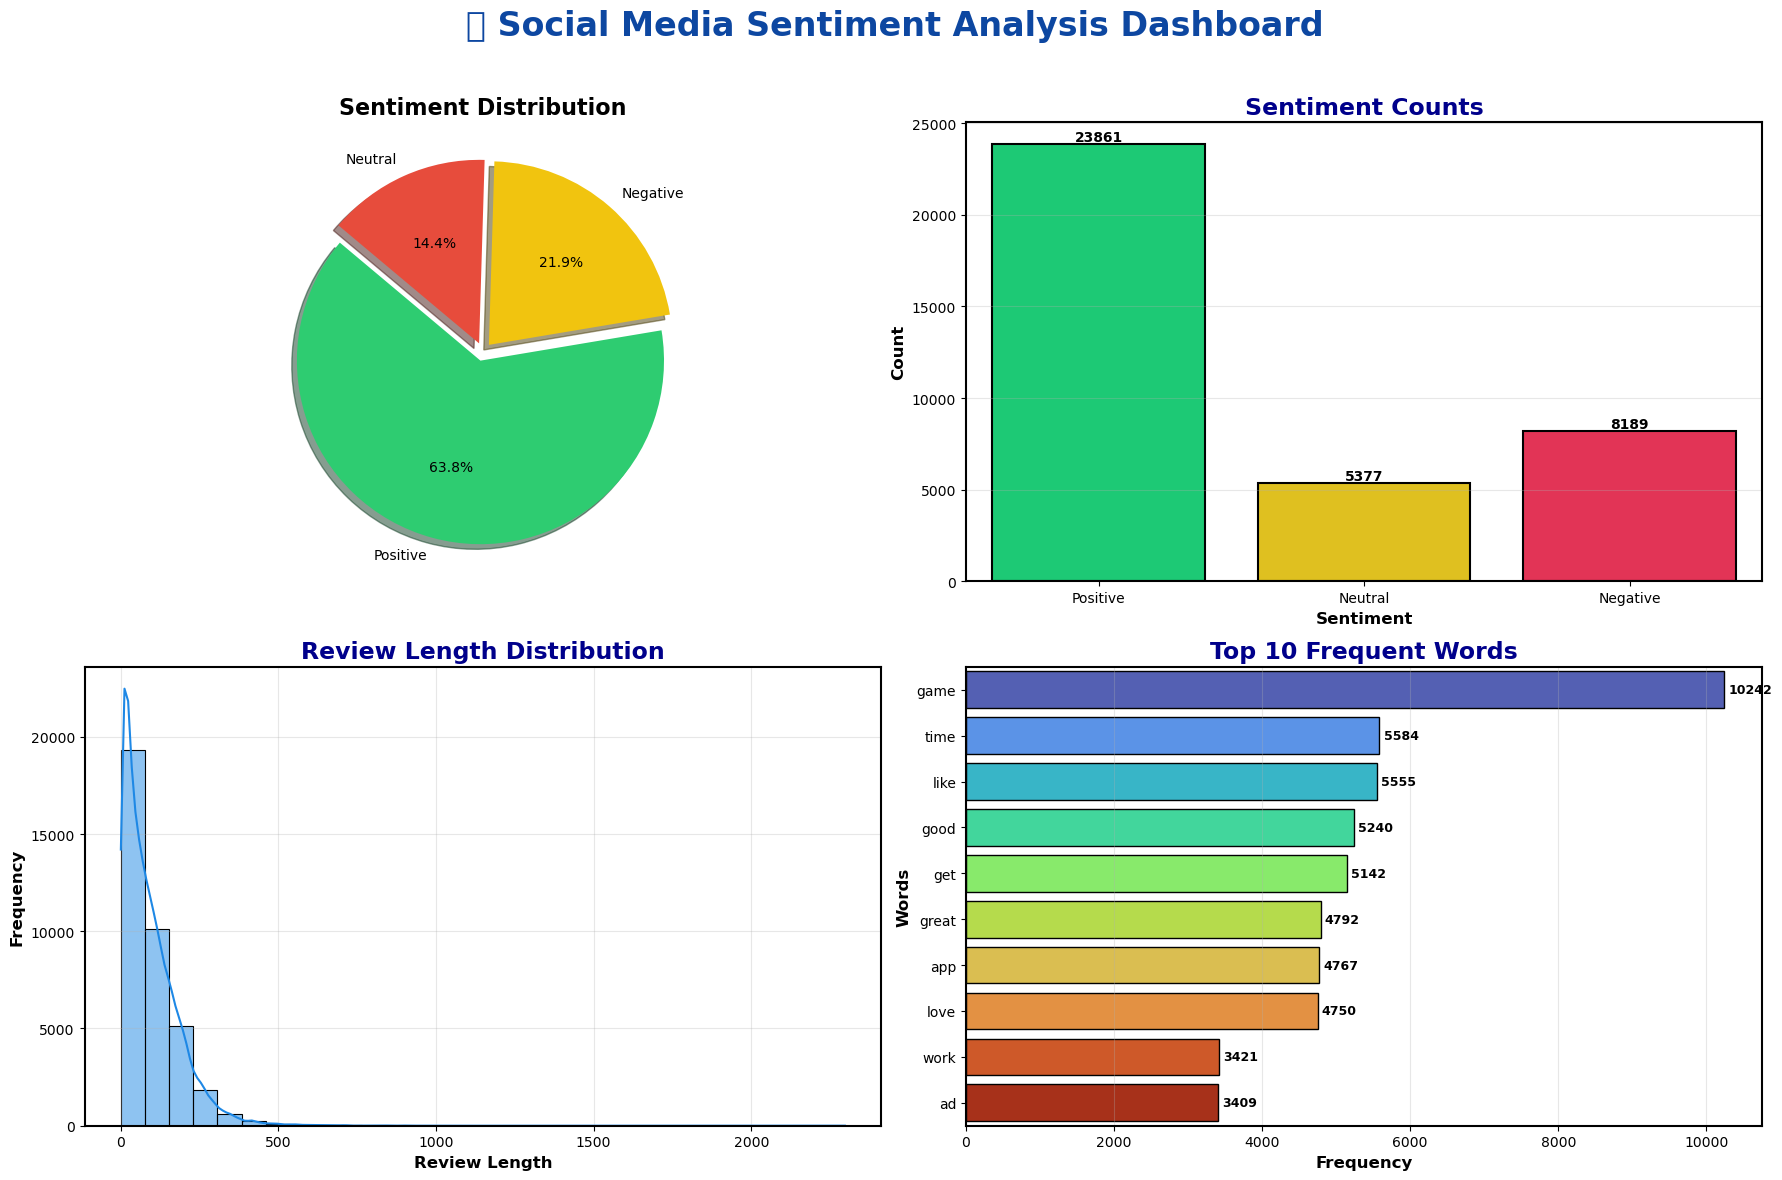

In [66]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(18, 12)
)

# -----------------------------
# 1. Pie Chart
# -----------------------------
pie_colors = ['#2ECC71', '#F1C40F', '#E74C3C']

axes[0,0].pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=pie_colors,
    startangle=140,
    explode=[0.05,0.05,0.05],
    shadow=True
)

axes[0,0].set_title(
    "Sentiment Distribution",
    fontsize=16,
    fontweight='bold'
)
# -----------------------------
# 2. Count Plot
# -----------------------------
count_colors = ['#00E676', '#FFD600', '#FF1744']

ax1 = sns.countplot(
    x='Predicted_Sentiment',
    data=df,
    order=['Positive', 'Neutral', 'Negative'],
    palette=count_colors,
    edgecolor='black',
    linewidth=1.5,
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Sentiment Counts",
    fontsize=17,
    fontweight='bold',
    color='darkblue'
)

axes[0,1].set_xlabel(
    "Sentiment",
    fontsize=12,
    fontweight='bold'
)

axes[0,1].set_ylabel(
    "Count",
    fontsize=12,
    fontweight='bold'
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        fontsize=10,
        fontweight='bold'
    )

axes[0,1].grid(axis='y', alpha=0.3)

# -----------------------------
# 3. Histogram
# -----------------------------
sns.histplot(
    df["Review_Length"],
    bins=30,
    color='#1E88E5',
    edgecolor='black',
    linewidth=0.8,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Review Length Distribution",
    fontsize=17,
    fontweight='bold',
    color='darkblue'
)

axes[1,0].set_xlabel(
    "Review Length",
    fontsize=12,
    fontweight='bold'
)

axes[1,0].set_ylabel(
    "Frequency",
    fontsize=12,
    fontweight='bold'
)

axes[1,0].grid(alpha=0.3)

# -----------------------------
# 4. Top Words
# -----------------------------
word_colors = sns.color_palette(
    "turbo",
    len(top_words_df.head(10))
)

ax2 = sns.barplot(
    x="Frequency",
    y="Word",
    data=top_words_df.head(10),
    palette=word_colors,
    edgecolor='black',
    linewidth=1,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Top 10 Frequent Words",
    fontsize=17,
    fontweight='bold',
    color='darkblue'
)

axes[1,1].set_xlabel(
    "Frequency",
    fontsize=12,
    fontweight='bold'
)

axes[1,1].set_ylabel(
    "Words",
    fontsize=12,
    fontweight='bold'
)

for container in ax2.containers:
    ax2.bar_label(
        container,
        fontsize=9,
        fontweight='bold',
        padding=3
    )

axes[1,1].grid(axis='x', alpha=0.3)

# -----------------------------
# Add Border Around Each Plot
# -----------------------------
for ax in axes.flat:
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('black')

# -----------------------------
# Dashboard Title
# -----------------------------
fig.suptitle(
    "📊 Social Media Sentiment Analysis Dashboard",
    fontsize=24,
    fontweight='bold',
    color='#0D47A1'
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

# Final Business Insights

### Customer Satisfaction
Majority of reviews are Positive indicating high customer satisfaction.

### Common Issues
- App crashes
- Slow performance
- Bugs after updates

### Most Requested Features
- Better User Interface
- Faster Performance
- New Functionalities

### Recommendations
- Fix recurring bugs
- Improve application speed
- Enhance user experience
- Prioritize customer requested features

### Product Improvement Insights

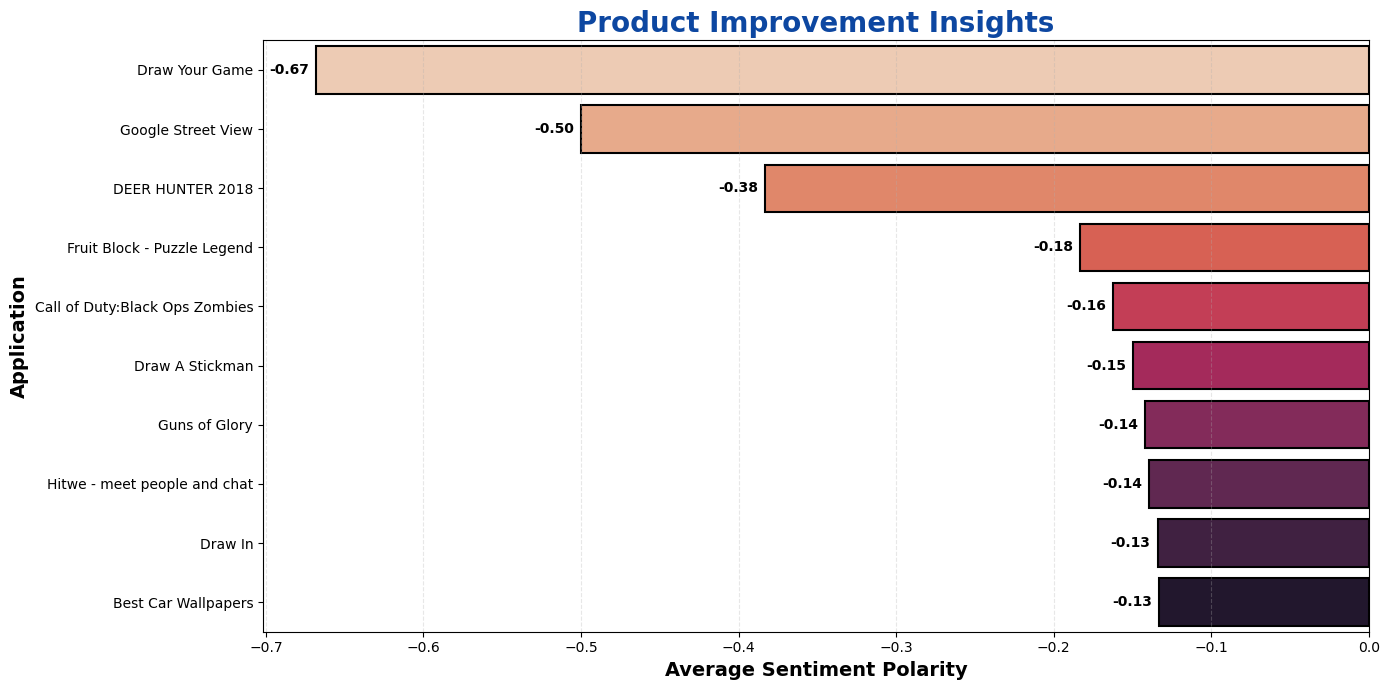

In [67]:
# Calculate average sentiment polarity for each app
improvement_df = (
    df.groupby("App")["Sentiment_Polarity"]
      .mean()
      .sort_values()
      .reset_index()
)

# Show the 10 apps with the lowest average polarity
improvement_df = improvement_df.head(10)

plt.figure(figsize=(14,7))

colors = sns.color_palette("rocket_r", len(improvement_df))

ax = sns.barplot(
    x="Sentiment_Polarity",
    y="App",
    data=improvement_df,
    palette=colors,
    edgecolor="black",
    linewidth=1.5
)

# Display polarity values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        fontsize=10,
        fontweight="bold",
        padding=5
    )

plt.title(
    "Product Improvement Insights",
    fontsize=20,
    fontweight="bold",
    color="#0D47A1"
)

plt.xlabel(
    "Average Sentiment Polarity",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Application",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Most Common Negative Words

In [68]:
# Filter negative reviews
negative_reviews = df[df['Predicted_Sentiment'] == 'Negative']

# Combine all cleaned reviews
negative_text = " ".join(negative_reviews['Cleaned_Review'].dropna())

# Remove common words (optional but recommended)
custom_stopwords = {
    'app','apps','use','used','using','get','got','one','would',
    'could','also','really','still','even','like','can','dont',
    'didnt','im','ive','make','made'
}

words = [
    word for word in negative_text.split()
    if word not in custom_stopwords and len(word) > 2
]

# Count word frequencies
word_counts = Counter(words)

# Most common negative words
negative_words_df = pd.DataFrame(
    word_counts.most_common(20),
    columns=['Negative Word', 'Frequency']
)

# Display the table
print(negative_words_df)

   Negative Word  Frequency
0           game       4852
1           time       1818
2           cant       1077
3           play       1016
4         update        853
5          level        853
6          phone        751
7            bad        722
8           work        715
9         please        685
10          back        648
11         every        641
12           fix        628
13          want        618
14          need        587
15         money        565
16      annoying        558
17          star        557
18          keep        528
19           way        517


### Feature Improvement Analysis

- Relevant features are derived from raw data to improve analysis and model performance.
- This step transforms data into a more meaningful and usable format.

#### Creating Feature Categories

In [69]:
# Product Improvement Feature Categories

feature_keywords = {

    "Performance": [
        "slow", "lag", "loading", "performance",
        "speed", "freeze", "crash", "stuck"
    ],

    "Bug Fixes": [
        "bug", "bugs", "error", "issue",
        "problem", "fix", "broken", "fail"
    ],

    "User Interface": [
        "design", "interface", "layout",
        "navigation", "ui", "theme"
    ],

    "Feature Enhancement": [
        "feature", "features", "option",
        "update", "version", "add",
        "improve", "improvement"
    ],

    "Account & Login": [
        "login", "signin", "account",
        "password", "register", "authentication"
    ],

    "Notifications": [
        "notification", "notifications",
        "alert", "reminder"
    ],

    "Advertisements": [
        "ads", "advertisement",
        "advertisements", "popup", "banner"
    ],

    "Battery & Storage": [
        "battery", "drain",
        "storage", "memory", "space"
    ]
}

#### Creating the feature mapping function

In [70]:
def map_feature(review):

    # Handle missing values
    if pd.isna(review):
        return "General Feedback"

    review = str(review).lower()

    for feature, keywords in feature_keywords.items():
        if any(keyword in review for keyword in keywords):
            return feature

    return "General Feedback"

In [71]:
# Creating the Feature Category Column

df["Feature"] = df["Cleaned_Review"].apply(map_feature)

In [72]:
# Display the Results
df[["Cleaned_Review", "Feature"]].head(10)

,Cleaned_Review,Feature
0,like eat delicious food thats im cooking food ...,General Feedback
1,help eating healthy exercise regular basis,General Feedback
3,work great especially going grocery store,General Feedback
4,best idea u,General Feedback
5,best way,General Feedback
6,amazing,General Feedback
8,looking forward app,General Feedback
9,helpful site help food get,General Feedback
10,good,General Feedback
11,useful information amount spelling error quest...,Bug Fixes


In [73]:
# Counting Each Feature Category

feature_counts = (
    df["Feature"]
    .value_counts()
    .reset_index()
)

feature_counts.columns = [
    "Feature Category",
    "Number of Reviews"
]

display(feature_counts)

,Feature Category,Number of Reviews
0,General Feedback,21699
1,Feature Enhancement,4646
2,Bug Fixes,4376
3,Performance,2911
4,User Interface,2324
5,Account & Login,701
6,Notifications,334
7,Battery & Storage,297
8,Advertisements,139


#### Function

In [74]:
def map_feature(review):

    # Handle missing values
    if pd.isna(review):
        return "General Feedback"

    # Convert review to lowercase
    review = str(review).lower()

    # Check each feature category
    for feature, keywords in feature_keywords.items():
        for keyword in keywords:
            if keyword in review:
                return feature

    # Default category
    return "General Feedback"

In [75]:
# Function to map reviews to product improvement features

def map_feature(review):
    review = str(review).lower()

    if any(word in review for word in ['crash', 'bug', 'error', 'freeze']):
        return 'Bug Fixes'

    elif any(word in review for word in ['slow', 'performance', 'lag']):
        return 'Performance'

    elif any(word in review for word in ['design', 'interface', 'ui', 'layout']):
        return 'User Interface'

    elif any(word in review for word in ['update', 'feature', 'option']):
        return 'Feature Enhancement'

    elif any(word in review for word in ['login', 'account', 'password']):
        return 'Account & Security'

    else:
        return 'General Feedback'

# Create Feature column
df['Feature'] = df['Cleaned_Review'].apply(map_feature)

# Display the first few rows
df[['Cleaned_Review', 'Feature']].head(10)

,Cleaned_Review,Feature
0,like eat delicious food thats im cooking food ...,General Feedback
1,help eating healthy exercise regular basis,General Feedback
3,work great especially going grocery store,General Feedback
4,best idea u,General Feedback
5,best way,General Feedback
6,amazing,General Feedback
8,looking forward app,General Feedback
9,helpful site help food get,General Feedback
10,good,General Feedback
11,useful information amount spelling error quest...,Bug Fixes


#### Feature Count

In [76]:
feature_counts = df['Feature'].value_counts()

display(feature_counts)

Feature
General Feedback       27242
Feature Enhancement     3458
User Interface          2620
Bug Fixes               2280
Performance              915
Account & Security       912
Name: count, dtype: int64

In [77]:
df.to_csv(
    "sentiment_analysis_output.csv",
    index=False
)

print("Output Saved Successfully")

Output Saved Successfully


### 10 Queries Related To The Code

#### Query 1: Number of Reviews for Each Feature Category

In [78]:
feature_counts = df['Feature'].value_counts()

display(feature_counts)

Feature
General Feedback       27242
Feature Enhancement     3458
User Interface          2620
Bug Fixes               2280
Performance              915
Account & Security       912
Name: count, dtype: int64

#### Query 2: Average Review Length by Feature Category

In [79]:
df.groupby('Feature')['Review_Length'].mean().sort_values(ascending=False)

Feature
User Interface         166.007634
Feature Enhancement    154.656160
Account & Security     144.347588
Performance            140.229508
Bug Fixes              137.547368
General Feedback        75.357169
Name: Review_Length, dtype: float64

### Query 3: Top 10 Apps with Highest Average Sentiment Polarity

In [80]:
df.groupby('App')['Sentiment_Polarity'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

App
HomeWork                                              1.000000
Google Slides                                         0.933333
Daily Workouts - Exercise Fitness Routine Trainer     0.800000
Bed Time Fan - White Noise Sleep Sounds               0.781250
Cameringo Lite. Filters Camera                        0.770269
Google Primer                                         0.750000
GPS Map Free                                          0.700000
GPS Speedometer and Odometer                          0.687500
Best Ovulation Tracker Fertility Calendar App Glow    0.595313
3D Live Neon Weed Launcher                            0.568182
Name: Sentiment_Polarity, dtype: float64

#### Query 4: Top 10 Apps with Lowest Average Sentiment Polarity

In [81]:
df.groupby('App')['Sentiment_Polarity'] \
  .mean() \
  .sort_values() \
  .head(10)

App
Draw Your Game                   -0.668490
Google Street View               -0.500000
DEER HUNTER 2018                 -0.383333
Fruit Block - Puzzle Legend      -0.183333
Call of Duty:Black Ops Zombies   -0.162120
Draw A Stickman                  -0.150000
Guns of Glory                    -0.142060
Hitwe - meet people and chat     -0.139456
Draw In                          -0.134167
Best Car Wallpapers              -0.133333
Name: Sentiment_Polarity, dtype: float64

#### Query 5: Number of Positive, Neutral and Negative Reviews per App

In [82]:
pd.crosstab(df['App'], df['Predicted_Sentiment'])

Predicted_Sentiment,Negative,Neutral,Positive
App,,,
10 Best Foods for You,12,26,156
104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,31
11st,7,9,23
1800 Contacts - Lens Store,8,10,62
1LINE – One Line with One Touch,8,3,27
...,...,...,...
Hotels.com: Book Hotel Rooms & Find Vacation Deals,19,10,39
Hotspot Shield Free VPN Proxy & Wi-Fi Security,3,14,17
Hotstar,15,3,14


#### Query 6: Average Sentiment Subjectivity by Sentiment

In [83]:
df.groupby('Predicted_Sentiment')['Sentiment_Subjectivity'].mean()

Predicted_Sentiment
Negative    0.533088
Neutral     0.099011
Positive    0.567665
Name: Sentiment_Subjectivity, dtype: float64

#### Query 7: Top 10 Most Reviewed Applications

In [84]:
df['App'].value_counts().head(10)

App
Bowmasters                        312
Helix Jump                        273
Angry Birds Classic               273
Calorie Counter - MyFitnessPal    254
Duolingo: Learn Languages Free    240
Candy Crush Saga                  240
Garena Free Fire                  222
8 Ball Pool                       219
Calorie Counter - Macros          200
10 Best Foods for You             194
Name: count, dtype: int64

#### Query 8: Average Review Length by Application

In [85]:
df.groupby('App')['Review_Length'] \
  .mean() \
  .sort_values(ascending=False) \
  .head(10)

App
Calendar+ Schedule Planner App                   301.000000
Dashlane Free Password Manager                   286.500000
Android Auto - Maps, Media, Messaging & Voice    280.741935
Couple - Relationship App                        269.869565
Hacker's Keyboard                                247.675000
Fallout Shelter                                  243.781250
Homescapes                                       236.211538
Crunchyroll - Everything Anime                   235.550000
Final Fantasy XV: A New Empire                   233.843750
Evie Launcher                                    226.093750
Name: Review_Length, dtype: float64

#### Query 9: Percentage Distribution of Sentiments

In [86]:
(
    df['Predicted_Sentiment']
    .value_counts(normalize=True)
    * 100
).round(2)

Predicted_Sentiment
Positive    63.75
Negative    21.88
Neutral     14.37
Name: proportion, dtype: float64

#### Query 10: Average Sentiment Polarity by Feature Category

In [87]:
df.groupby('Feature')['Sentiment_Polarity'] \
  .mean() \
  .sort_values(ascending=False)

Feature
General Feedback       0.212198
User Interface         0.159627
Feature Enhancement    0.141930
Bug Fixes              0.044222
Account & Security     0.033541
Performance           -0.003312
Name: Sentiment_Polarity, dtype: float64

# Conclusion

This project successfully analyzed customer reviews using Python-based data analysis and Natural Language Processing (NLP) techniques. The dataset was cleaned, preprocessed, and analyzed to identify positive, negative, and neutral sentiments from user reviews.

Exploratory Data Analysis (EDA) and various visualizations, including sentiment distribution, review length analysis, word frequency analysis, word clouds, and application-wise review analysis, provided valuable insights into customer opinions and behavior. The results indicate that while a majority of users expressed positive feedback, negative reviews highlighted recurring issues such as performance, bugs, updates, and usability concerns.

The findings demonstrate how sentiment analysis can help organizations understand customer needs, improve user satisfaction, and make data-driven decisions for product enhancement. Overall, this project illustrates the practical application of Python, data analysis, and NLP techniques in extracting meaningful insights from unstructured textual data.